In [42]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas
from pprint import pprint

In [47]:
with open('./data/datasetsTable2026-6-1.json', 'r') as f:
    js = json.load(f)

####view an example scan data
#pprint(js[293])



##commented keys are mostly constant for all the scans
keys = [
        'scanID', # 102442
        'start time',# '2026-05-28T10:23:38.443620'
        #'SAXS_Z', #2499.9000000000015
        #'Table_x', #8.436050000000002|-3.733550000000001
        #'Table_y', #8.436050000000002|-3.733550000000001
        #'bs_x', #25.29850508905855|40.130327608142366
        #'bs_y', #25.29850508905855|40.130327608142366
        'description', #position [1-5]
        'Total number frames',# 5|10
        'end time',# '2026-05-28T10:23:38.443620'
        #'sams3_x', #3x:11.3, 3y:-5.5005, 4x:119.98464999999999, 4y:39.322200000000066
        #'sams3_y', #3x:11.3, 3y:-5.5005, 4x:119.98464999999999, 4y:39.322200000000066
        'sams4_x', #3x:11.3, 3y:-5.5005, 4x:119.98464999999999, 4y:39.322200000000066
        'sams4_y', #3x:11.3, 3y:-5.5005, 4x:119.98464999999999, 4y:39.322200000000066
        'title', #timescan 10 0.1 0.0
       ]

def extract_scan_info(d):
    out_dir = {}
    if 'comment' in d.keys():
        out_dir['comment'] = d['comment']
    else:
        out_dir['comment'] = ''
    for key in keys:
        out_dir[key] = d['scientificMetadata'][key]['value']
    return out_dir

out_list = [out_d for out_d in map(lambda d:extract_scan_info(d), js)]

    


In [48]:
## check which values are unique to see what we can delete
#df = pandas.DataFrame(out_list)
#for key in keys:
#    print(key, '\t', df[key].unique())


In [51]:
df.to_csv('./data/scans_clean.csv')
df


,comment,scanID,start time,description,Total number frames,end time,sams4_x,sams4_y,title
0,,103624,2026-05-29T22:53:23.697546,,1,2026-05-29T22:53:29.101350,116.66355,29.45525,timescan 1 0.1 0.0
1,,103623,2026-05-29T22:53:15.387985,,1,2026-05-29T22:53:20.135806,116.66355,29.45520,timescan 1 0.1 0.0
2,,103622,2026-05-29T22:52:39.631841,,1,2026-05-29T22:52:44.118719,116.58500,26.97280,timescan 1 0.1 0.0
3,,103621,2026-05-29T22:52:22.611167,,1,2026-05-29T22:52:26.338113,116.58500,26.97335,timescan 1 0.1 0.0
4,,103620,2026-05-29T22:52:08.473632,,1,2026-05-29T22:52:14.094355,116.58500,26.97375,timescan 1 0.1 0.0
...,...,...,...,...,...,...,...,...,...
1184,,102437,2026-05-28T08:41:03.368110,position 1,1,2026-05-28T08:41:08.222247,133.18370,23.83820,timescan 1 0.1 0.0
1185,,102436,2026-05-28T08:36:15.937759,position 1,1,2026-05-28T08:36:20.290364,133.18370,23.83825,timescan 1 0.1 0.0
1186,,102435,2026-05-28T08:35:21.210892,position 1,1,2026-05-28T08:35:26.177672,133.18365,23.83820,timescan 1 0.1 0.0
1187,,102434,2026-05-28T08:19:16.676553,position 1,1,2026-05-28T08:19:23.114464,33.18630,23.83815,timescan 1 0.1 0.0


(26.0, 34.0)

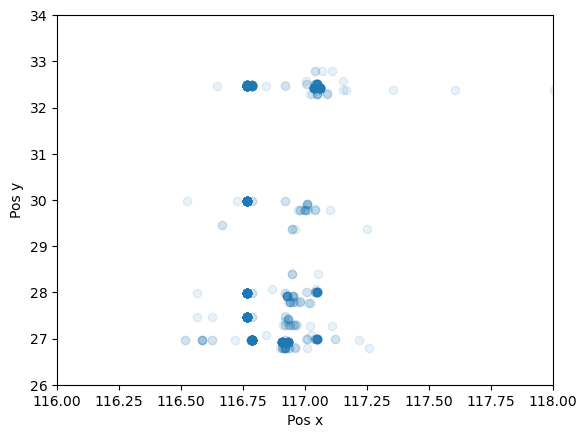

In [70]:
plt.figure()
plt.scatter(df['sams4_x'], df['sams4_y'], alpha=0.1)
plt.xlabel('Pos x')
plt.ylabel('Pos y')
plt.xlim([116, 118])
plt.ylim([26,34])